In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/google-stock-prices-2015-2024/GoogleStockPrices.csv


In [2]:
df = pd.read_csv("/kaggle/input/google-stock-prices-2015-2024/GoogleStockPrices.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,2015-01-02 16:00:00,26.63,26.79,26.39,26.48,1327870
1,2015-01-05 16:00:00,26.36,26.40,25.89,25.97,2059119
2,2015-01-06 16:00:00,26.02,26.06,25.28,25.33,2731813
3,2015-01-07 16:00:00,25.55,25.57,25.18,25.26,2345875
4,2015-01-08 16:00:00,25.08,25.38,24.75,25.35,3662224


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2516 non-null   object 
 1   Open    2516 non-null   float64
 2   High    2516 non-null   float64
 3   Low     2516 non-null   float64
 4   Close   2516 non-null   float64
 5   Volume  2516 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 118.1+ KB


In [4]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df = df.set_index('Date')
df = df.sort_index()

df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02 16:00:00,26.63,26.79,26.39,26.48,1327870
2015-01-05 16:00:00,26.36,26.40,25.89,25.97,2059119
2015-01-06 16:00:00,26.02,26.06,25.28,25.33,2731813
2015-01-07 16:00:00,25.55,25.57,25.18,25.26,2345875
2015-01-08 16:00:00,25.08,25.38,24.75,25.35,3662224


In [8]:
#check frequency of data

df.index.to_series().diff().value_counts()

Date
1 days 00:00:00    1965
3 days 00:00:00     442
4 days 00:00:00      69
2 days 00:00:00       7
1 days 21:00:00       5
3 days 03:00:00       5
0 days 21:00:00       4
2 days 03:00:00       4
1 days 21:05:00       3
3 days 02:55:00       3
2 days 02:55:00       3
0 days 21:05:00       2
2 days 21:00:00       1
4 days 03:00:00       1
2 days 21:05:00       1
Name: count, dtype: int64

In [9]:
df['Volume'] = df['Volume'].astype(float)
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02 16:00:00,26.63,26.79,26.39,26.48,1327870.0
2015-01-05 16:00:00,26.36,26.40,25.89,25.97,2059119.0
2015-01-06 16:00:00,26.02,26.06,25.28,25.33,2731813.0
2015-01-07 16:00:00,25.55,25.57,25.18,25.26,2345875.0
2015-01-08 16:00:00,25.08,25.38,24.75,25.35,3662224.0


In [10]:
# Any Close > High? or Close < Low?
df[(df['Close'] > df['High']) | (df['Close'] < df['Low'])]


,Open,High,Low,Close,Volume
Date,,,,,


In [11]:
df.to_csv("cleaned_google_stock.csv")


# Data Visualization

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

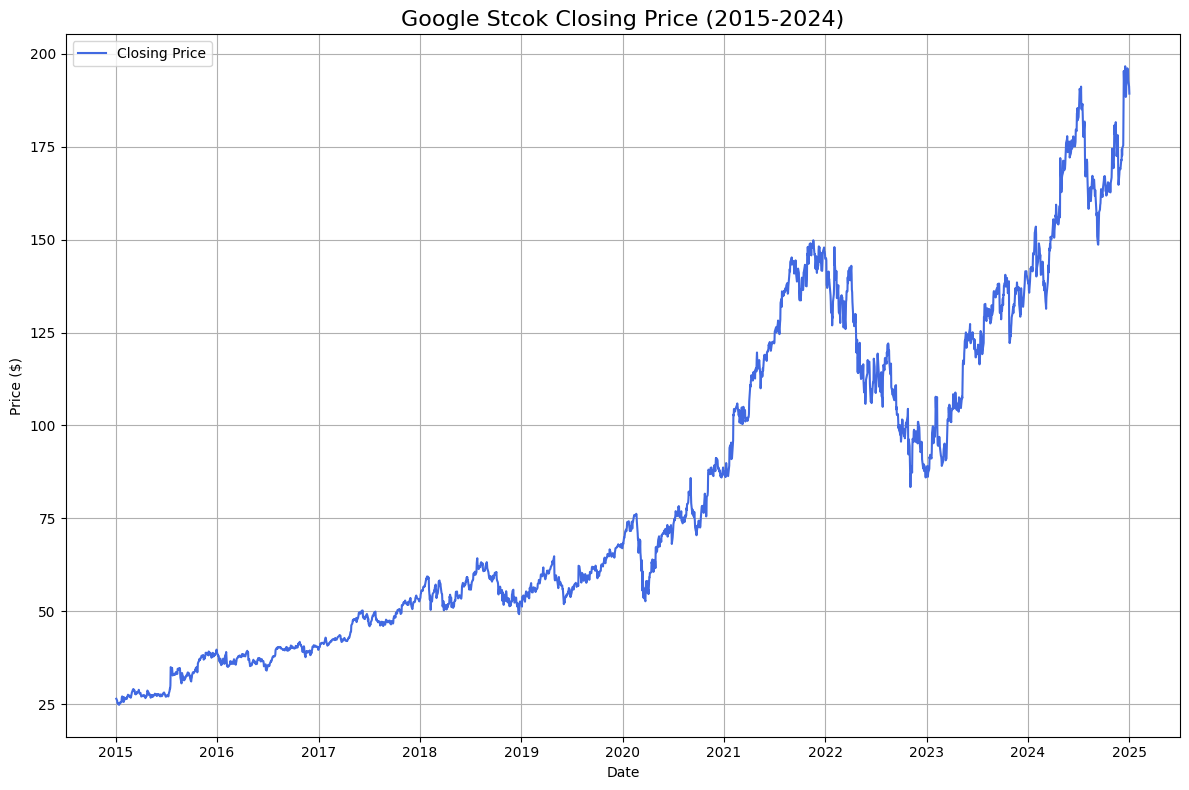

In [13]:
plt.figure(figsize=(12,8))
plt.plot(df['Close'], label='Closing Price', color='royalblue')
plt.title('Google Stcok Closing Price (2015-2024)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['Close'], mode='lines', name='Close', line=dict(color='blue')))
fig.update_layout(title='Google Stock Closing Price (2015–2024)',
                  xaxis_title='Date',
                  yaxis_title='Price ($)',
                  template='plotly_white')
fig.show()


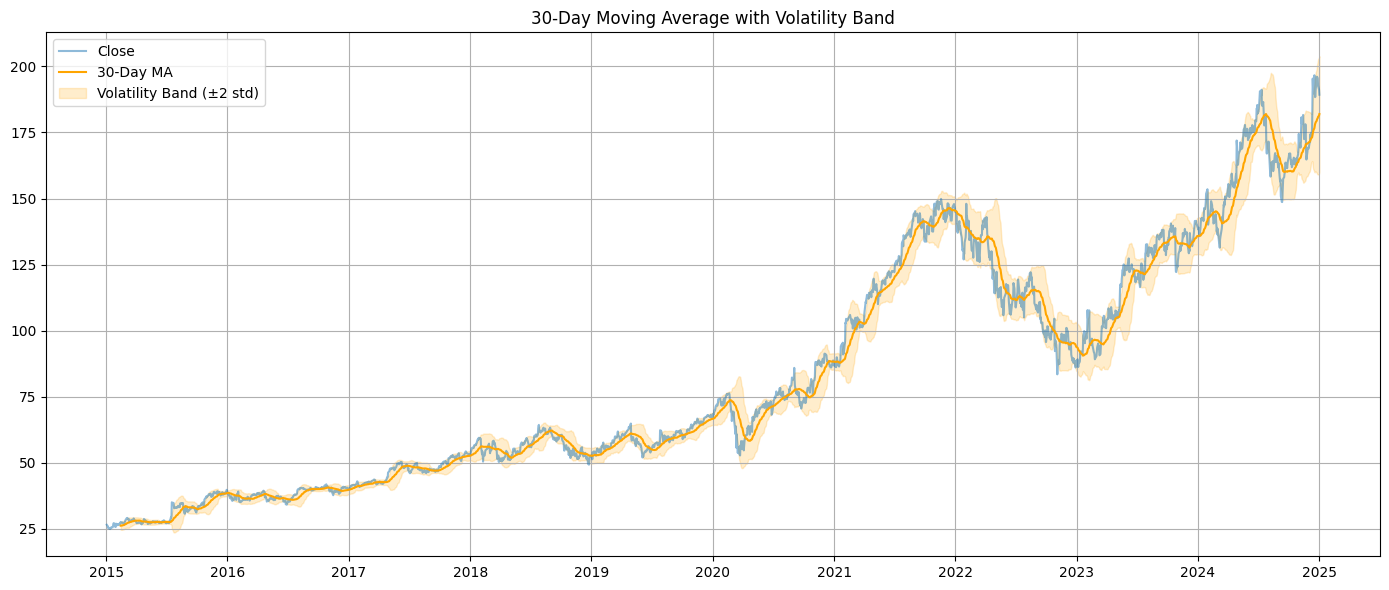

In [15]:
df['Rolling_Mean_30'] = df['Close'].rolling(window=30).mean()
df['Rolling_STD_30'] = df['Close'].rolling(window=30).std()

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close', alpha=0.5)
plt.plot(df['Rolling_Mean_30'], label='30-Day MA', color='orange')
plt.fill_between(df.index,
                 df['Rolling_Mean_30'] - 2*df['Rolling_STD_30'],
                 df['Rolling_Mean_30'] + 2*df['Rolling_STD_30'],
                 color='orange', alpha=0.2, label='Volatility Band (±2 std)')
plt.title('30-Day Moving Average with Volatility Band')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
import plotly.express as px

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['Close'], mode='lines', name='Close'))
fig.add_trace(go.Scatter(x=df.index, y=df['Rolling_Mean_30'], mode='lines', name='30-Day MA'))
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['Rolling_Mean_30'] + 2 * df['Rolling_STD_30'],
    mode='lines',
    name='Upper Band',
    line=dict(dash='dash', color='gray')
))
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['Rolling_Mean_30'] - 2 * df['Rolling_STD_30'],
    mode='lines',
    name='Lower Band',
    line=dict(dash='dash', color='gray'),
    fill='tonexty', fillcolor='rgba(200,200,200,0.2)'
))
fig.update_layout(title='Close Price with 30-Day MA and ±2 Std Dev Bands',
                  template='plotly_white')
fig.show()


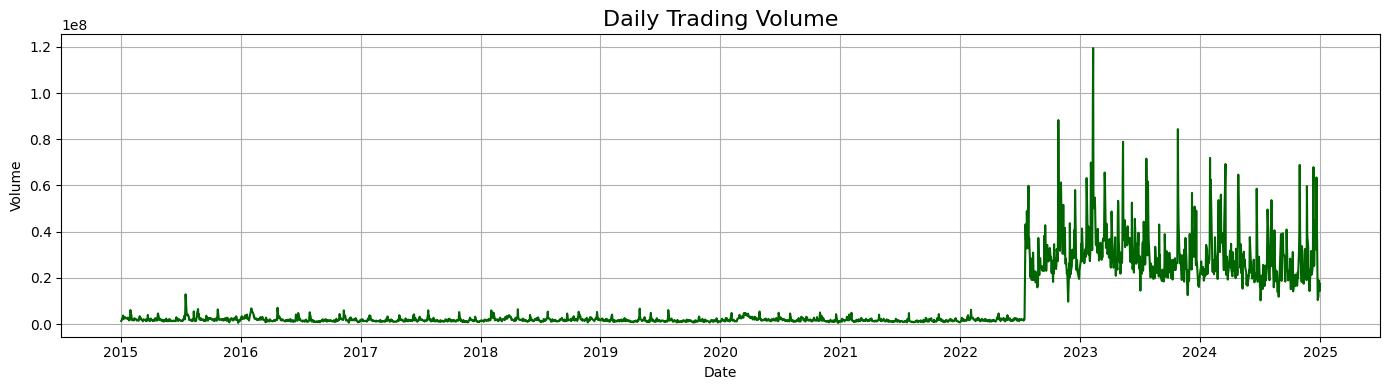

In [17]:
plt.figure(figsize=(14,4))
plt.plot(df['Volume'], color='darkgreen')
plt.title('Daily Trading Volume', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['Volume'], mode='lines', name='Volume', line=dict(color='green')))
fig.update_layout(title='Daily Trading Volume', xaxis_title='Date', yaxis_title='Volume', template='plotly_white')
fig.show()


In [19]:
fig = go.Figure(data=[go.Candlestick(x=df.index,
                                     open=df['Open'],
                                     high=df['High'],
                                     low=df['Low'],
                                     close=df['Close'])])
fig.update_layout(title='Candlestick Chart of Google Stock', template='plotly_white')
fig.show()


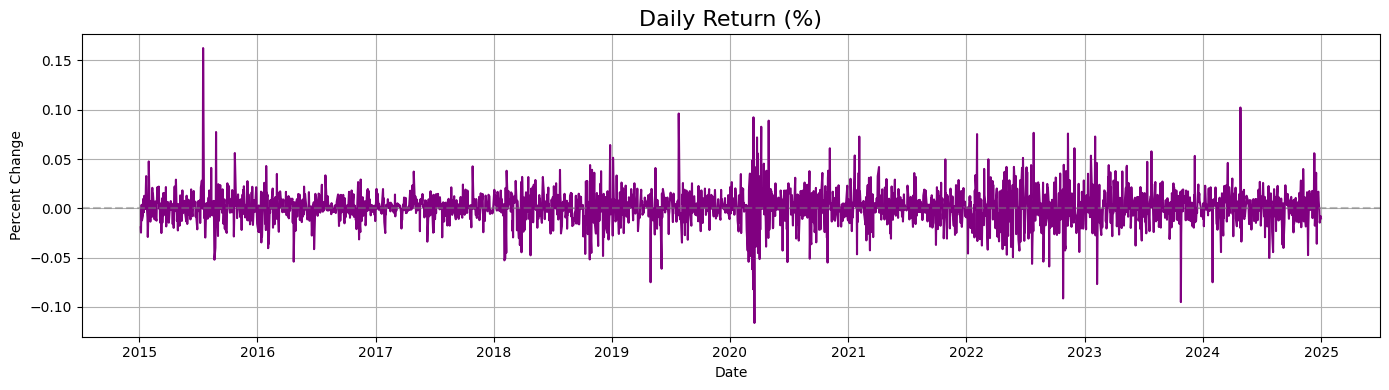

In [20]:
df['Daily_Return'] = df['Close'].pct_change()

plt.figure(figsize=(14,4))
plt.plot(df['Daily_Return'], color='purple')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Daily Return (%)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Percent Change')
plt.grid(True)
plt.tight_layout()
plt.show()


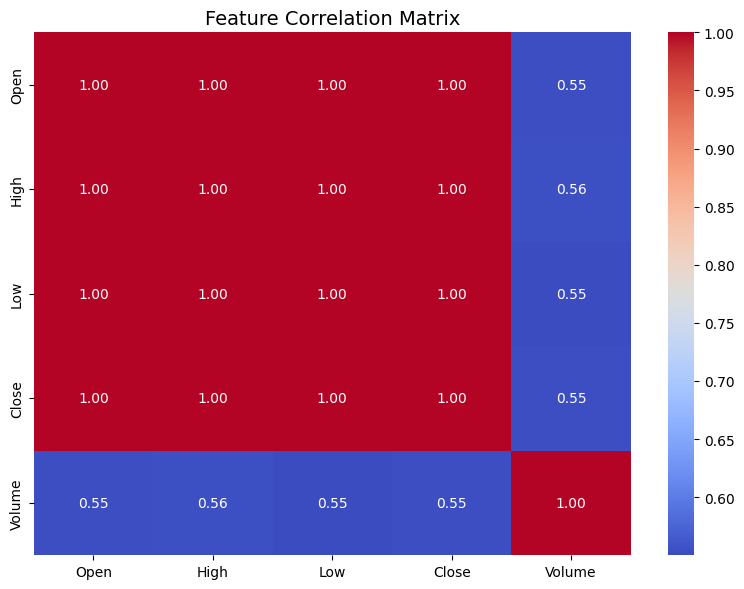

In [21]:

corr = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()


# Z-Score + Rolling Mean (Statistical Anomaly Detection)

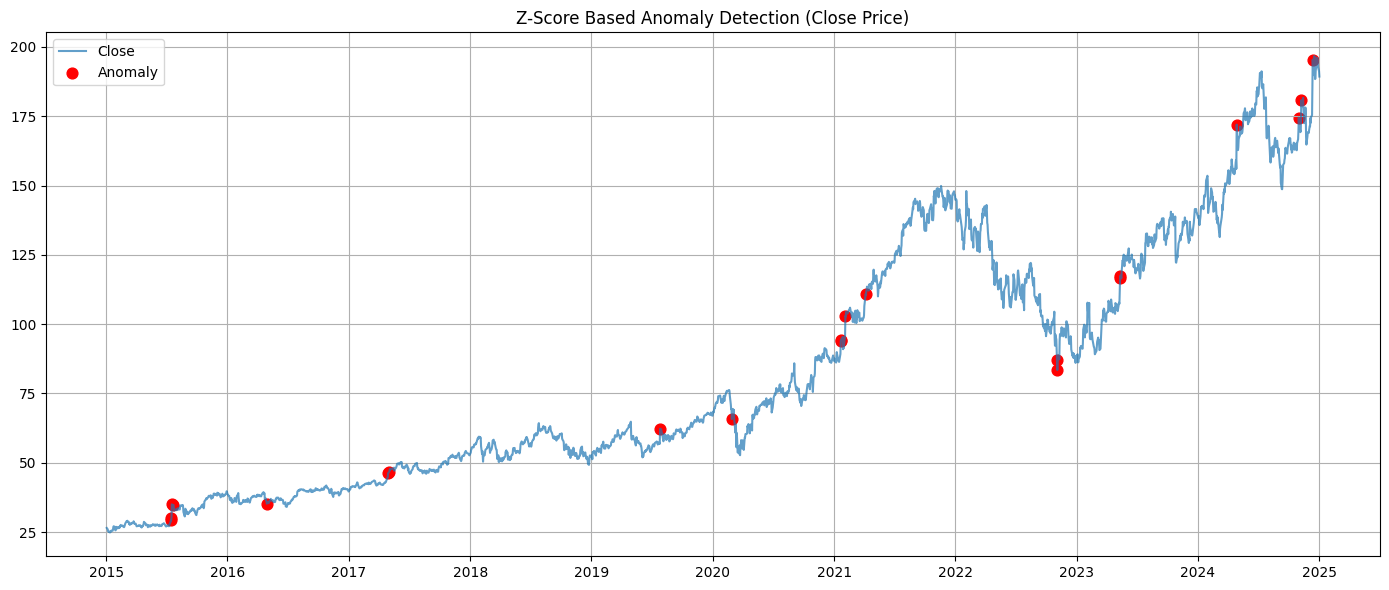

In [22]:
# Rolling statistics
rolling_mean = df['Close'].rolling(window=30).mean()
rolling_std = df['Close'].rolling(window=30).std()

# Z-score calculation
df['z_score'] = (df['Close'] - rolling_mean) / rolling_std

# Flag anomalies: abs(Z) > 3 (3-sigma rule)
df['anomaly_zscore'] = df['z_score'].apply(lambda x: 1 if abs(x) > 3 else 0)

# Plot anomalies on Close Price
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close', alpha=0.7)
plt.scatter(df[df['anomaly_zscore'] == 1].index,
            df[df['anomaly_zscore'] == 1]['Close'],
            color='red', label='Anomaly', s=60)
plt.title('Z-Score Based Anomaly Detection (Close Price)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#  Isolation Forest (Unsupervised Machine Learning)

/tmp/ipykernel_13/2669678987.py:5: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning:

X does not have valid feature names, but IsolationForest was fitted with feature names



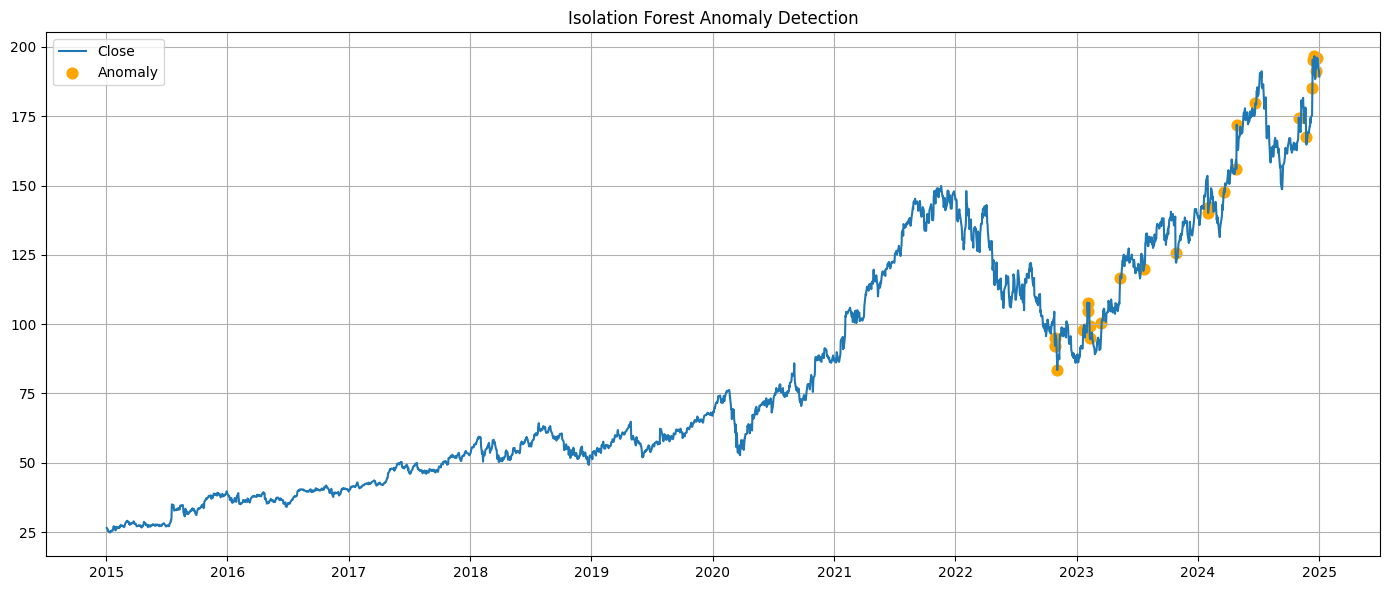

In [23]:
from sklearn.ensemble import IsolationForest

# Model input features
features = df[['Close', 'Volume']].copy()
features.fillna(method='bfill', inplace=True)

# Fit model
iso = IsolationForest(contamination=0.01, random_state=42)
df['anomaly_iso'] = iso.fit_predict(features)

# Map: -1 → anomaly, 1 → normal
df['anomaly_iso'] = df['anomaly_iso'].map({1: 0, -1: 1})

# Plot
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close')
plt.scatter(df[df['anomaly_iso'] == 1].index,
            df[df['anomaly_iso'] == 1]['Close'],
            color='orange', label='Anomaly', s=60)
plt.title('Isolation Forest Anomaly Detection')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Prophet Changepoint Detection

In [24]:
pip install prophet


Note: you may need to restart the kernel to use updated packages.


12:11:05 - cmdstanpy - INFO - Chain [1] start processing
12:11:06 - cmdstanpy - INFO - Chain [1] done processing


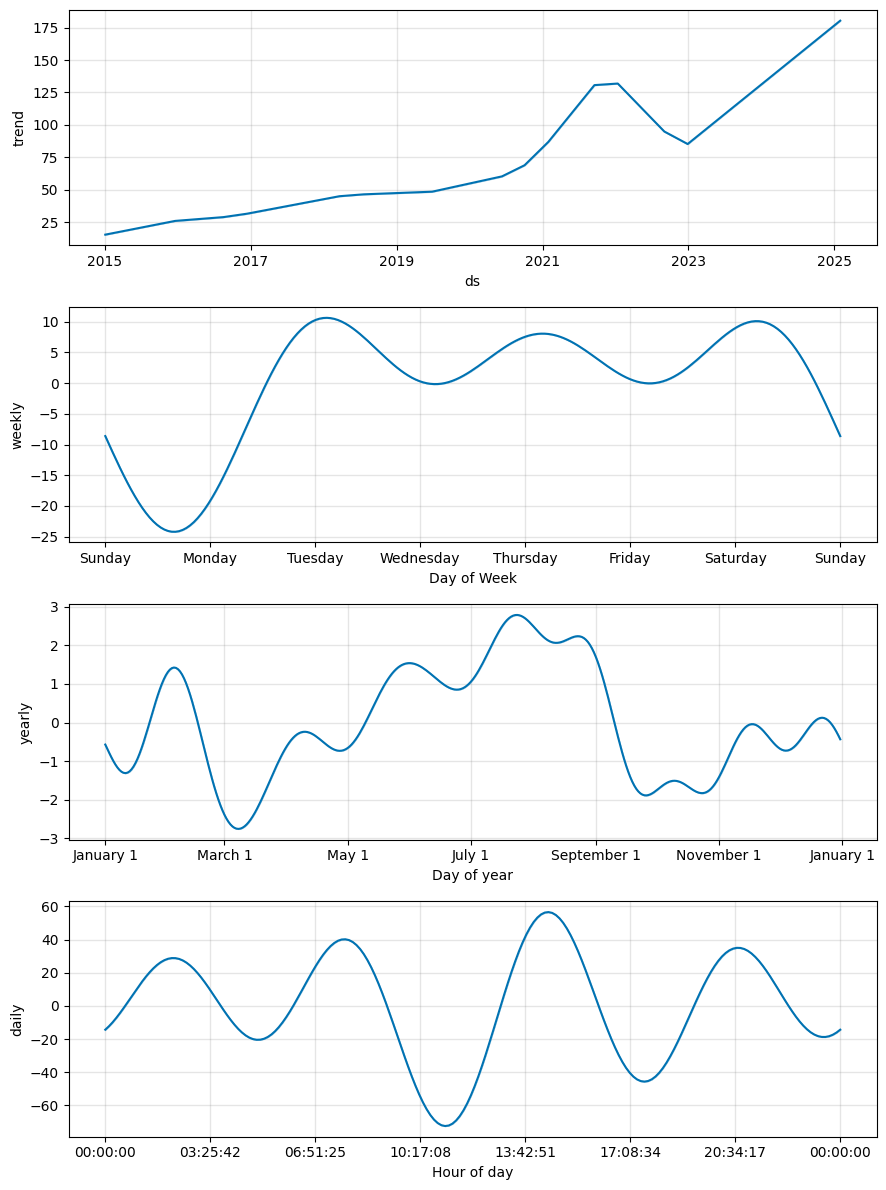

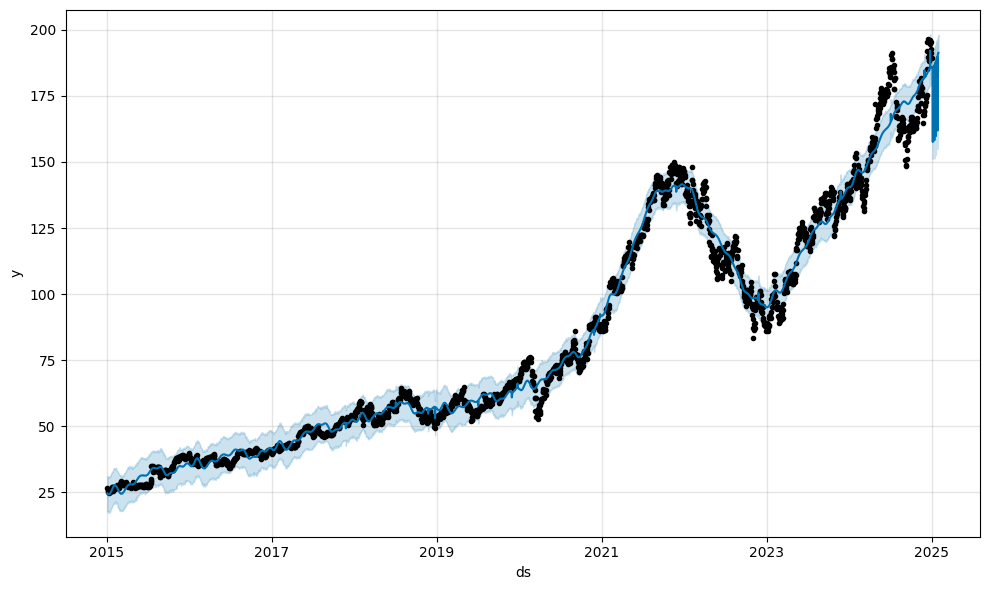

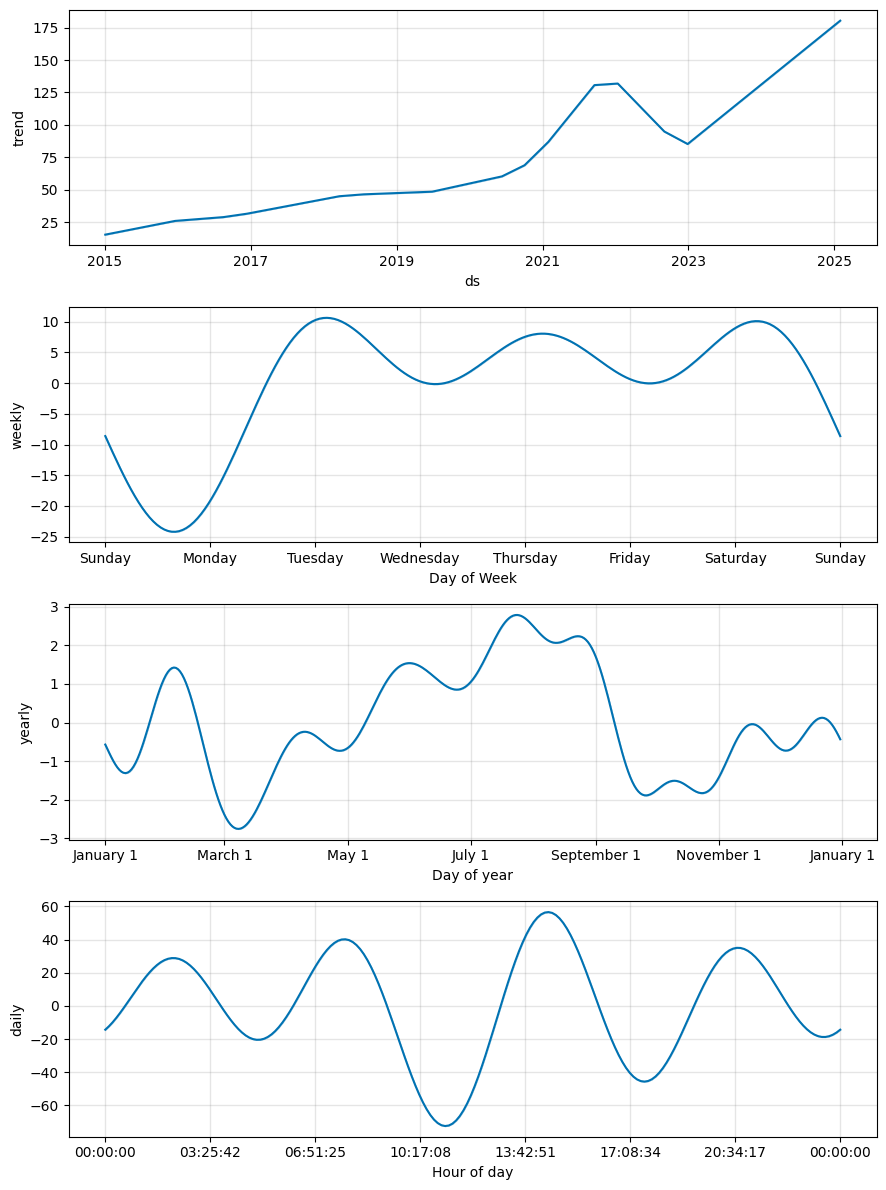

In [25]:
from prophet import Prophet

# Prepare for Prophet
prophet_df = df[['Close']].reset_index().rename(columns={'Date': 'ds', 'Close': 'y'})

model = Prophet()
model.fit(prophet_df)

# Forecast
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Plot changepoints
fig = model.plot(forecast)
model.plot_components(forecast)


# LSTM Autoencoder

2025-07-21 12:11:11.112227: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753099871.338976      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753099871.414419      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-21 12:11:26.932830: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instea

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - loss: 0.0542 - val_loss: 0.0463
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0026 - val_loss: 0.0074
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 6.8162e-04 - val_loss: 0.0112
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 4.6528e-04 - val_loss: 0.0033
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 4.8207e-04 - val_loss: 0.0035
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 3.8007e-04 - val_loss: 0.0026
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 3.3629e-04 - val_loss: 0.0031
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 3.4233e-04 - val_loss: 0.0019
Epoch 9/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 3.4140e-04 - val_loss: 0.0021
Epoch 10/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 3.1876e-04 - val_loss: 0.0021
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step


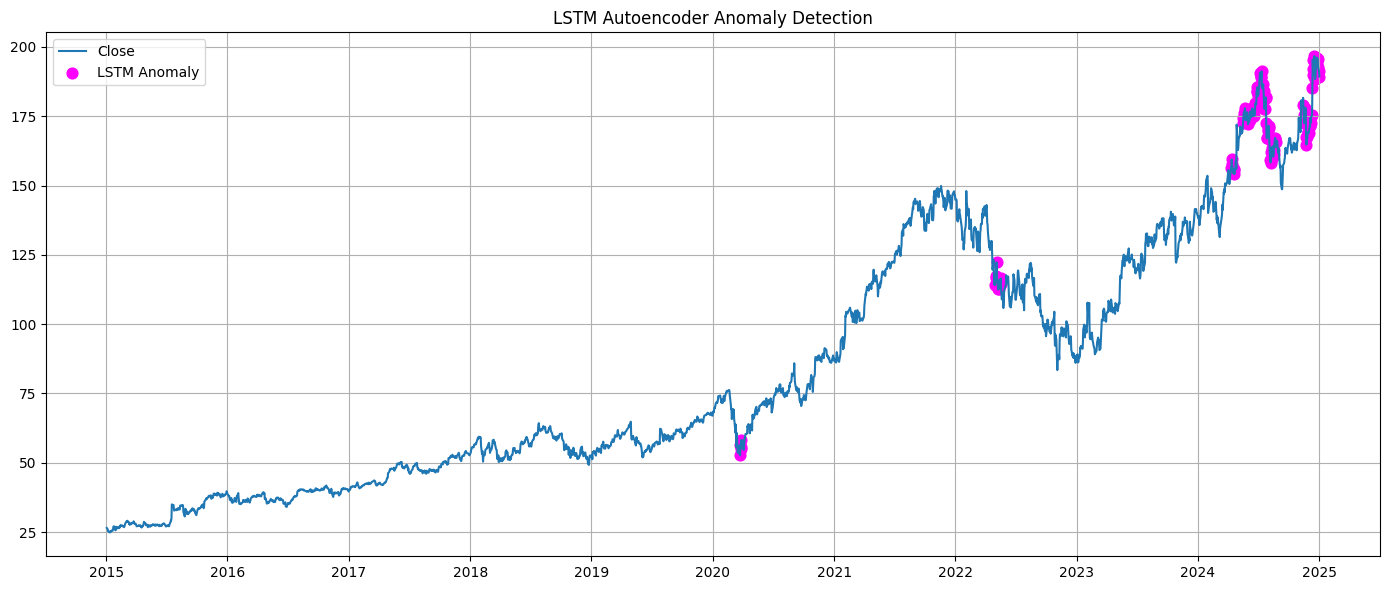

In [26]:
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, RepeatVector, TimeDistributed, Dense

# Prepare data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Close']].values)

# Windowing
def create_sequences(data, window=30):
    sequences = []
    for i in range(len(data) - window):
        sequences.append(data[i:i + window])
    return np.array(sequences)

X = create_sequences(scaled_data)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Autoencoder model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(X.shape[1], 1), return_sequences=False),
    RepeatVector(X.shape[1]),
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(1))
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, X, epochs=10, batch_size=32, validation_split=0.1)

# Reconstruction error
X_pred = model.predict(X)
mse = np.mean(np.power(X - X_pred, 2), axis=(1,2))
threshold = np.percentile(mse, 95)

# Align with original data
df['anomaly_lstm'] = 0
df.iloc[30:, df.columns.get_loc('anomaly_lstm')] = (mse > threshold).astype(int)

# Plot
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close')
plt.scatter(df[df['anomaly_lstm'] == 1].index,
            df[df['anomaly_lstm'] == 1]['Close'],
            color='magenta', label='LSTM Anomaly', s=60)
plt.title('LSTM Autoencoder Anomaly Detection')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
df.to_csv('anomaly_results.csv')


In [28]:
df[['Close', 'anomaly_zscore']].to_csv('anomaly_zscore.csv')


In [29]:
df[['Close', 'Volume', 'anomaly_iso']].to_csv('anomaly_isolation_forest.csv')


In [30]:
df[['Close', 'anomaly_lstm']].to_csv('anomaly_lstm_autoencoder.csv')


In [31]:
df[['Close', 'Volume', 'anomaly_zscore', 'anomaly_iso', 'anomaly_lstm']].to_csv('all_anomalies_combined.csv')
